# Germline-AA-stratified analyses at entrenched sites

## Motivation

DASM identified a set of **within-family entrenched sites** (Chothia positions 33, 35, 50, 52, 53)
that sit at or near the heavy–light chain interface. A natural hypothesis is that the entrenched
selection signal is driven by **epistasis with the light chain partner**: different germline amino
acids at these sites may be compatible with different light chains, and substitutions that disrupt
the pairing are selected against.

If light chain identity drives the entrenched selection, then the observed/expected substitution
rate at these sites should **differ systematically** between heavy chains paired with kappa vs.
lambda light chains, or across finer-grained LC V gene subgroups. We test this by stratifying by
**germline amino acid** — each dot represents one germline AA mutating away to anything else at a
given (site, V family) — so that composition differences across V genes do not confound the comparison.

## Two analyses

1. **Analysis A** — kappa vs. lambda: $|\Delta \log(O/E)|$ per (site, V family, germline AA).
   Does the mutation rate at a given germline residue differ between kappa-paired and lambda-paired heavy chains?
2. **Analysis B** — variance of $\log(O/E)$ across LC V gene subgroups per (site, V family, germline AA).
   Is there heterogeneity in mutation rates across LC V gene subgroups for a given germline residue?

## Summary of results

**Neither analysis finds evidence that entrenched sites are special compared to non-entrenched sites.**

- **Permutation test** (site-label shuffle, 10,000 permutations): p = 0.48 for Analysis A, p = 0.12
  for Analysis B. Entrenched sites do not have systematically higher kappa-vs-lambda differences or
  higher variance across subgroups.
- **Outlier detection** (MAD-based robust z-scores, BH-corrected): Analysis A finds 19 outlier triples
  across all sites, but only 3 are at entrenched sites — no enrichment beyond chance. Analysis B finds
  no significant outliers at all.
- **Noise-corrected variance**: ~57% of non-entrenched and ~54% of entrenched triples have variance
  fully explained by Poisson counting noise.

Some individual entrenched-site triples do show elevated values (e.g., site 52/IGHV3/R in Analysis A,
site 50/IGHV1/W in Analysis B), but comparable or larger signals appear at non-entrenched sites with
no biological reason to show LC-dependent selection (e.g., site 90/IGHV4/Y, site 44/IGHV3/G),
suggesting these are noise.

## Limitations: this analysis only tests selection during affinity maturation

This analysis can only detect LC-dependent selection **during affinity maturation** — i.e.,
differential selection on heavy chain mutations depending on which light chain the heavy chain
is paired with in an existing clonal family.

However, selection on heavy–light chain compatibility also acts at an earlier stage: **B cell
development** (receptor editing and developmental selection in the bone marrow). If HC–LC epistasis
drives entrenchment, Stage 1 filtering would remove incompatible pairings *before* clonal families
ever form. By the time DASM measures selection during affinity maturation, each heavy chain is already
embedded in its compatible LC context. Both kappa-paired and lambda-paired heavy chains would then
show similar purifying selection — not because epistasis is absent, but because the "wrong" pairings
were already eliminated.

**The absence of signal here does not rule out HC–LC epistasis as the driver of entrenchment.** It
only shows that LC-dependent selection is not detectable during affinity maturation, which is exactly
what one would expect if the epistatic filtering already occurred during development. A direct test of
the epistasis hypothesis would require examining initial (pre-selection) pairing frequencies rather
than the post-selection repertoire that DASM operates on.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

from utils import (
    load_and_process_dnsm_data, load_entrenched_sites, add_germline_information,
    sort_antibody_sites, add_cdr_shading
)
from dnsmex.neutral_mutability import CachedNeutralMutabilityDataset
from dnsmex.dxsm_data import dataset_dict
from rates_analysis_util import add_mutation_counts_per_branch_for_branch_length

In [2]:
DATASET = 'v1jaffe'
numbering_scheme = 'chothia'
BRANCH_LENGTH_METHOD = 'mutation_frequency'
BRANCH_LENGTH_SCALE_FACTOR = 1.60
pseudocount = 0.5

# Per-(site, v_family, parent_aa) thresholds for the kappa-vs-lambda analysis.
min_expected_aa = 10
min_observed_aa = 10

# Per-(site, v_family, parent_aa, lc_v_subgroup) thresholds for the variance analysis.
min_expected_vgene_aa = 5
min_observed_vgene_aa = 5
min_vgene_subgroups_aa = 3

WITHIN_FAMILY_SITES = ['33', '35', '50', '52', '53']

In [3]:
# Use checkpoints if available; otherwise compute from raw data (slow).
# Checkpoints store UNFILTERED data so thresholds can be changed without recomputing.
CHECKPOINT_FILES = ['checkpoints/pivot_aa_lc.pkl', 'checkpoints/merge_vgene_aa.pkl']
USE_CHECKPOINTS = all(os.path.isfile(f) for f in CHECKPOINT_FILES)

if USE_CHECKPOINTS:
    print('Loading unfiltered checkpoints...')
    pivot_aa_lc = pd.read_pickle('checkpoints/pivot_aa_lc.pkl')
    merge_vgene_aa = pd.read_pickle('checkpoints/merge_vgene_aa.pkl')
else:
    print('No checkpoints found — computing from raw data...')

    # --- Load DNSM site-level data ---
    site_sub_probs_df, total_pcp_df = load_and_process_dnsm_data(
        model_name='dnsm_1m-v1jaffe+v1tang-joint',
        dataset_name=DATASET,
        numbering_scheme=numbering_scheme
    )
    site_sub_probs_df = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df)

    # --- Load Thrifty neutral model ---
    neutral_probs = CachedNeutralMutabilityDataset(
        dataset_nickname=DATASET,
        branch_length_mode=BRANCH_LENGTH_METHOD,
        branch_length_scale_factor=BRANCH_LENGTH_SCALE_FACTOR,
        numbering_scheme=numbering_scheme,
        skip_nucleotide=True,
    )
    neutral_probs.aa_neutral_df = add_germline_information(
        neutral_probs.pcp_df, neutral_probs.aa_neutral_df, numbering_scheme=numbering_scheme
    )
    neutral_probs.aa_to_any_neutral_df = add_germline_information(
        neutral_probs.pcp_df, neutral_probs.aa_to_any_neutral_df, numbering_scheme=numbering_scheme
    )

    # --- Light chain annotations ---
    paired_df = pd.read_csv(
        dataset_dict['v1jaffePaired'],
        usecols=['child_name', 'child_is_leaf', 'v_gene_light', 'light_chain_type']
    )
    paired_leaves = paired_df[paired_df.child_is_leaf][
        ['child_name', 'v_gene_light', 'light_chain_type']
    ].drop_duplicates(subset='child_name')
    jaffe_leaves = total_pcp_df[total_pcp_df.child_is_leaf][['sample_id', 'family', 'child_name']].copy()
    jaffe_leaves['child_name'] = jaffe_leaves['child_name'].astype(str)
    paired_leaves['child_name'] = paired_leaves['child_name'].astype(str)
    matched = jaffe_leaves.merge(paired_leaves, on='child_name', how='inner')
    family_lc = matched.groupby(['sample_id', 'family']).agg(
        light_chain_type=('light_chain_type', 'first'),
        v_gene_light=('v_gene_light', 'first')
    ).reset_index()
    family_lc['lc_v_subgroup'] = family_lc['v_gene_light'].str.split('-').str[0].str.split('*').str[0]
    total_pcp_df['pcp_index'] = total_pcp_df.index
    total_pcp_df = total_pcp_df.merge(family_lc, on=['sample_id', 'family'], how='left')

    # --- Observed counts, stratified by germline AA ---
    lc_by_pcp = total_pcp_df[['pcp_index', 'light_chain_type', 'lc_v_subgroup']].dropna(subset=['light_chain_type'])
    site_df_lc = site_sub_probs_df.merge(lc_by_pcp, on='pcp_index', how='inner')
    pcp_indices_non_leaf = set(total_pcp_df[~total_pcp_df['child_is_leaf']].pcp_index.values)
    obs_filtered = site_df_lc[
        (site_df_lc.is_germline_codon == True) &
        (site_df_lc.pcp_index.isin(pcp_indices_non_leaf)) &
        (site_df_lc.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))
    ]
    observed_any_aa_lc = obs_filtered.groupby(
        ['site', 'v_family', 'parent_aa', 'light_chain_type']
    ).mutation.sum().reset_index().rename(columns={'mutation': 'observed_counts'})
    observed_any_aa_vgene = obs_filtered.groupby(
        ['site', 'v_family', 'parent_aa', 'lc_v_subgroup']
    ).mutation.sum().reset_index().rename(columns={'mutation': 'observed_counts'})

    # --- Expected counts from Thrifty ---
    thrifty_pcp = neutral_probs.pcp_df.copy()
    thrifty_pcp['pcp_index_thrifty'] = thrifty_pcp.index
    thrifty_pcp = thrifty_pcp.drop(columns=['v_gene_light'], errors='ignore')
    thrifty_pcp = thrifty_pcp.merge(family_lc, on=['sample_id', 'family'], how='left')
    thrifty_lc_map = thrifty_pcp[['pcp_index_thrifty', 'light_chain_type', 'lc_v_subgroup']].dropna(subset=['light_chain_type'])
    thrifty_lc_map = thrifty_lc_map.rename(columns={'pcp_index_thrifty': 'pcp_index'})
    pcp_indices_non_leaf_thrifty = set(thrifty_pcp[~thrifty_pcp['child_is_leaf']].index)
    aa_to_any_lc = neutral_probs.aa_to_any_neutral_df.merge(thrifty_lc_map, on='pcp_index', how='inner')
    filtered_expected_any = aa_to_any_lc[
        (aa_to_any_lc.is_germline_codon == True) &
        (aa_to_any_lc.pcp_index.isin(pcp_indices_non_leaf_thrifty)) &
        (aa_to_any_lc.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))
    ]
    expected_any_aa_lc = filtered_expected_any.groupby(
        ['site', 'v_family', 'current_aa', 'light_chain_type']
    ).substitution_probability.sum().reset_index().rename(columns={
        'current_aa': 'parent_aa', 'substitution_probability': 'expected_counts'
    })
    expected_any_aa_vgene = filtered_expected_any.groupby(
        ['site', 'v_family', 'current_aa', 'lc_v_subgroup']
    ).substitution_probability.sum().reset_index().rename(columns={
        'current_aa': 'parent_aa', 'substitution_probability': 'expected_counts'
    })

    # --- Analysis A: merge and pivot kappa vs lambda ---
    merge_aa_lc = pd.merge(observed_any_aa_lc, expected_any_aa_lc,
        on=['site', 'v_family', 'parent_aa', 'light_chain_type'], how='inner')
    merge_aa_lc['log_ratio'] = np.log(
        (merge_aa_lc['observed_counts'] + pseudocount) /
        (merge_aa_lc['expected_counts'] + pseudocount)
    )
    pivot_aa_lc = merge_aa_lc.pivot_table(
        index=['site', 'v_family', 'parent_aa'],
        columns='light_chain_type',
        values=['log_ratio', 'observed_counts', 'expected_counts'],
        aggfunc='first'
    ).reset_index()
    pivot_aa_lc.columns = [
        f'{col[0]}_{col[1]}' if col[1] else col[0]
        for col in pivot_aa_lc.columns
    ]
    pivot_aa_lc = pivot_aa_lc.dropna(subset=['log_ratio_kappa', 'log_ratio_lambda'])
    pivot_aa_lc['delta_log_ratio'] = pivot_aa_lc['log_ratio_kappa'] - pivot_aa_lc['log_ratio_lambda']

    # --- Analysis B: merge for variance across LC V gene subgroups ---
    merge_vgene_aa = pd.merge(observed_any_aa_vgene, expected_any_aa_vgene,
        on=['site', 'v_family', 'parent_aa', 'lc_v_subgroup'], how='inner')
    merge_vgene_aa['log_ratio'] = np.log(
        (merge_vgene_aa['observed_counts'] + pseudocount) /
        (merge_vgene_aa['expected_counts'] + pseudocount)
    )

    # Save UNFILTERED checkpoints
    os.makedirs('checkpoints', exist_ok=True)
    pivot_aa_lc.to_pickle('checkpoints/pivot_aa_lc.pkl')
    merge_vgene_aa.to_pickle('checkpoints/merge_vgene_aa.pkl')
    print('Computed from raw data and saved unfiltered checkpoints/')

# --- Load entrenched sites (always needed) ---
_, _, _, _, within_dfs, _ = load_entrenched_sites(numbering_scheme)
within_dfs['site'] = within_dfs['site'].astype(str)
within_site_keys = set(zip(within_dfs['site'].astype(str), within_dfs['v_family']))

# --- Apply thresholds (uses current config values, runs fast) ---
well_powered_aa = pivot_aa_lc[
    (pivot_aa_lc['expected_counts_kappa'] >= min_expected_aa) &
    (pivot_aa_lc['expected_counts_lambda'] >= min_expected_aa) &
    (pivot_aa_lc['observed_counts_kappa'] >= min_observed_aa) &
    (pivot_aa_lc['observed_counts_lambda'] >= min_observed_aa)
].copy()
well_powered_aa['category'] = well_powered_aa.apply(
    lambda r: 'entrenched_site' if (str(r['site']), r['v_family']) in within_site_keys
              else 'non_entrenched', axis=1)

merge_vgene_aa_wp = merge_vgene_aa[
    (merge_vgene_aa['expected_counts'] >= min_expected_vgene_aa) &
    (merge_vgene_aa['observed_counts'] >= min_observed_vgene_aa)
].copy()
sg_counts = merge_vgene_aa_wp.groupby(['site', 'v_family', 'parent_aa']).lc_v_subgroup.nunique().reset_index()
sg_counts = sg_counts.rename(columns={'lc_v_subgroup': 'n_subgroups'})
enough_sg = sg_counts[sg_counts.n_subgroups >= min_vgene_subgroups_aa]
merge_vgene_aa_wp = merge_vgene_aa_wp.merge(
    enough_sg[['site', 'v_family', 'parent_aa']],
    on=['site', 'v_family', 'parent_aa'], how='inner')
variance_by_aa = merge_vgene_aa_wp.groupby(['site', 'v_family', 'parent_aa']).agg(
    var_log_ratio=('log_ratio', 'var'),
    mean_log_ratio=('log_ratio', 'mean'),
    n_subgroups=('lc_v_subgroup', 'nunique'),
).reset_index()
variance_by_aa['category'] = variance_by_aa.apply(
    lambda r: 'entrenched_site' if (str(r['site']), r['v_family']) in within_site_keys
              else 'non_entrenched', axis=1)

# Noise-corrected variance
poisson_floor = (
    merge_vgene_aa_wp
    .assign(inv_obs=lambda d: 1.0 / d['observed_counts'])
    .groupby(['site', 'v_family', 'parent_aa'])['inv_obs']
    .mean().rename('poisson_floor').reset_index()
)
variance_by_aa = variance_by_aa.merge(
    poisson_floor, on=['site', 'v_family', 'parent_aa'], how='left')
variance_by_aa['var_corrected'] = variance_by_aa['var_log_ratio'] - variance_by_aa['poisson_floor']

print(f'Well-powered kappa vs lambda triples: {len(well_powered_aa)}')
print(well_powered_aa['category'].value_counts())
print()
print(f'Variance triples: {len(variance_by_aa)}')
print(variance_by_aa['category'].value_counts())

Loading unfiltered checkpoints...
Well-powered kappa vs lambda triples: 368
category
non_entrenched     334
entrenched_site     34
Name: count, dtype: int64

Variance triples: 360
category
non_entrenched     325
entrenched_site     35
Name: count, dtype: int64


In [4]:
# Shared plotting constants
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')
aa_colors = {aa: c for aa, c in zip(AA_ORDER, plt.cm.tab20.colors[:len(AA_ORDER)])}
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

def highlight_entrenched_ticks(ax, sorted_sites, within_site_keys, vf):
    """Color x-tick labels red for entrenched sites."""
    for tick_label in ax.get_xticklabels():
        site = tick_label.get_text()
        if (site, vf) in within_site_keys:
            tick_label.set_color('red')
            tick_label.set_fontweight('bold')

def make_aa_legend(fig, present_aas):
    """Add a germline-AA color legend to the right of the figure."""
    handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=7,
                           markerfacecolor=aa_colors[aa], markeredgecolor='none', label=aa)
               for aa in sorted(present_aas)]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.06, 0.5),
               title='germline AA', frameon=False, fontsize=8)

---
## Analysis A: Kappa vs. lambda $|\Delta \log(O/E)|$ per germline AA

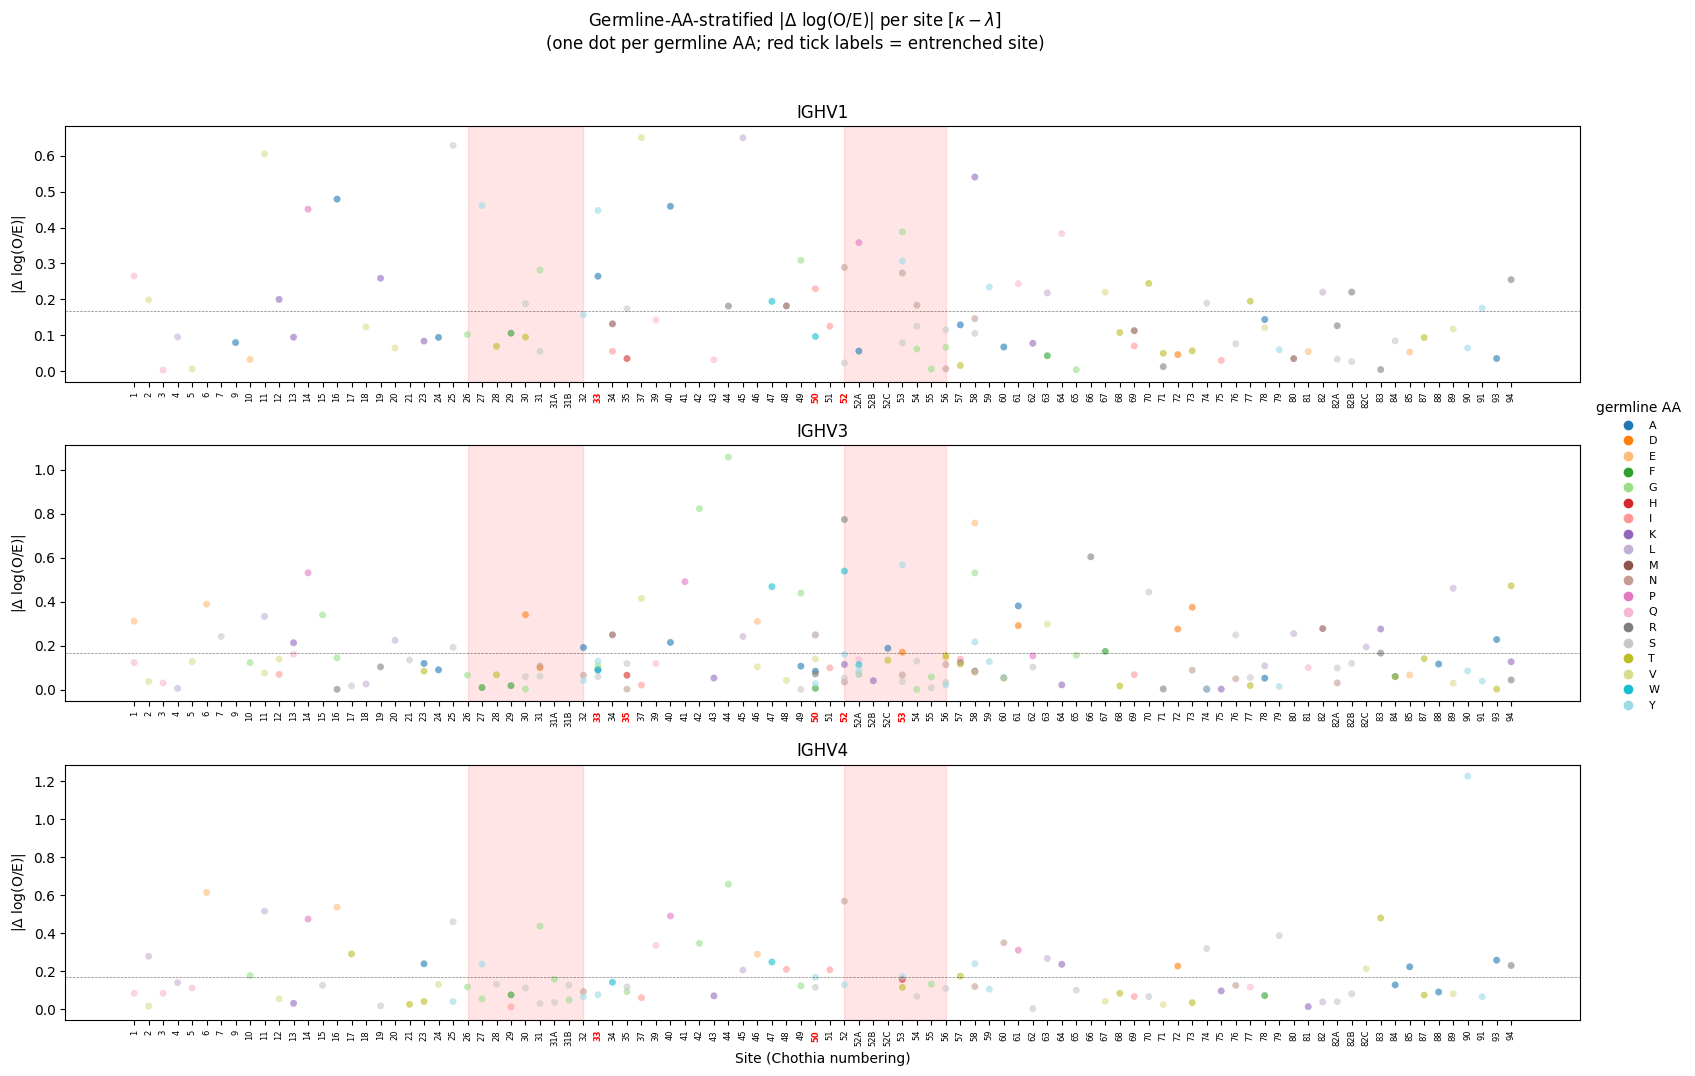

In [ ]:
sorted_sites_aa = sort_antibody_sites(well_powered_aa['site'].unique())
site_positions = {s: i for i, s in enumerate(sorted_sites_aa)}

non_ent_aa = well_powered_aa[well_powered_aa.category == 'non_entrenched']['delta_log_ratio']
baseline_aa = non_ent_aa.abs().mean()

fig, axes = plt.subplots(len(v_families), 1, figsize=(16, 3.5 * len(v_families)))

for ax, vf in zip(axes, v_families):
    vf_data = well_powered_aa[well_powered_aa.v_family == vf]
    add_cdr_shading(ax, sorted_sites_aa, numbering_scheme=numbering_scheme)
    ax.axhline(baseline_aa, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

    xs = [site_positions[s] for s in vf_data['site']]
    ys = vf_data['delta_log_ratio'].abs().values
    cs = [aa_colors.get(aa, 'black') for aa in vf_data['parent_aa']]
    ax.scatter(xs, ys, c=cs, marker='o', s=25, alpha=0.6, edgecolors='none')

    ax.set_ylabel(r'|$\Delta$ log(O/E)|')
    ax.set_title(f'{vf}')
    ax.set_xticks(range(len(sorted_sites_aa)))
    ax.set_xticklabels(sorted_sites_aa, rotation=90, fontsize=6)

axes[-1].set_xlabel('Site (Chothia numbering)')

fig.canvas.draw()
for ax, vf in zip(axes, v_families):
    highlight_entrenched_ticks(ax, sorted_sites_aa, within_site_keys, vf)

make_aa_legend(fig, well_powered_aa['parent_aa'].unique())
fig.suptitle(r'Germline-AA-stratified |$\Delta$ log(O/E)| per site [$\kappa - \lambda$]'
             '\n(one dot per germline AA; red tick labels = entrenched site)',
             y=1.02)
plt.tight_layout()
plt.show()

---
## Analysis B: Variance of $\log(O/E)$ across LC V gene subgroups

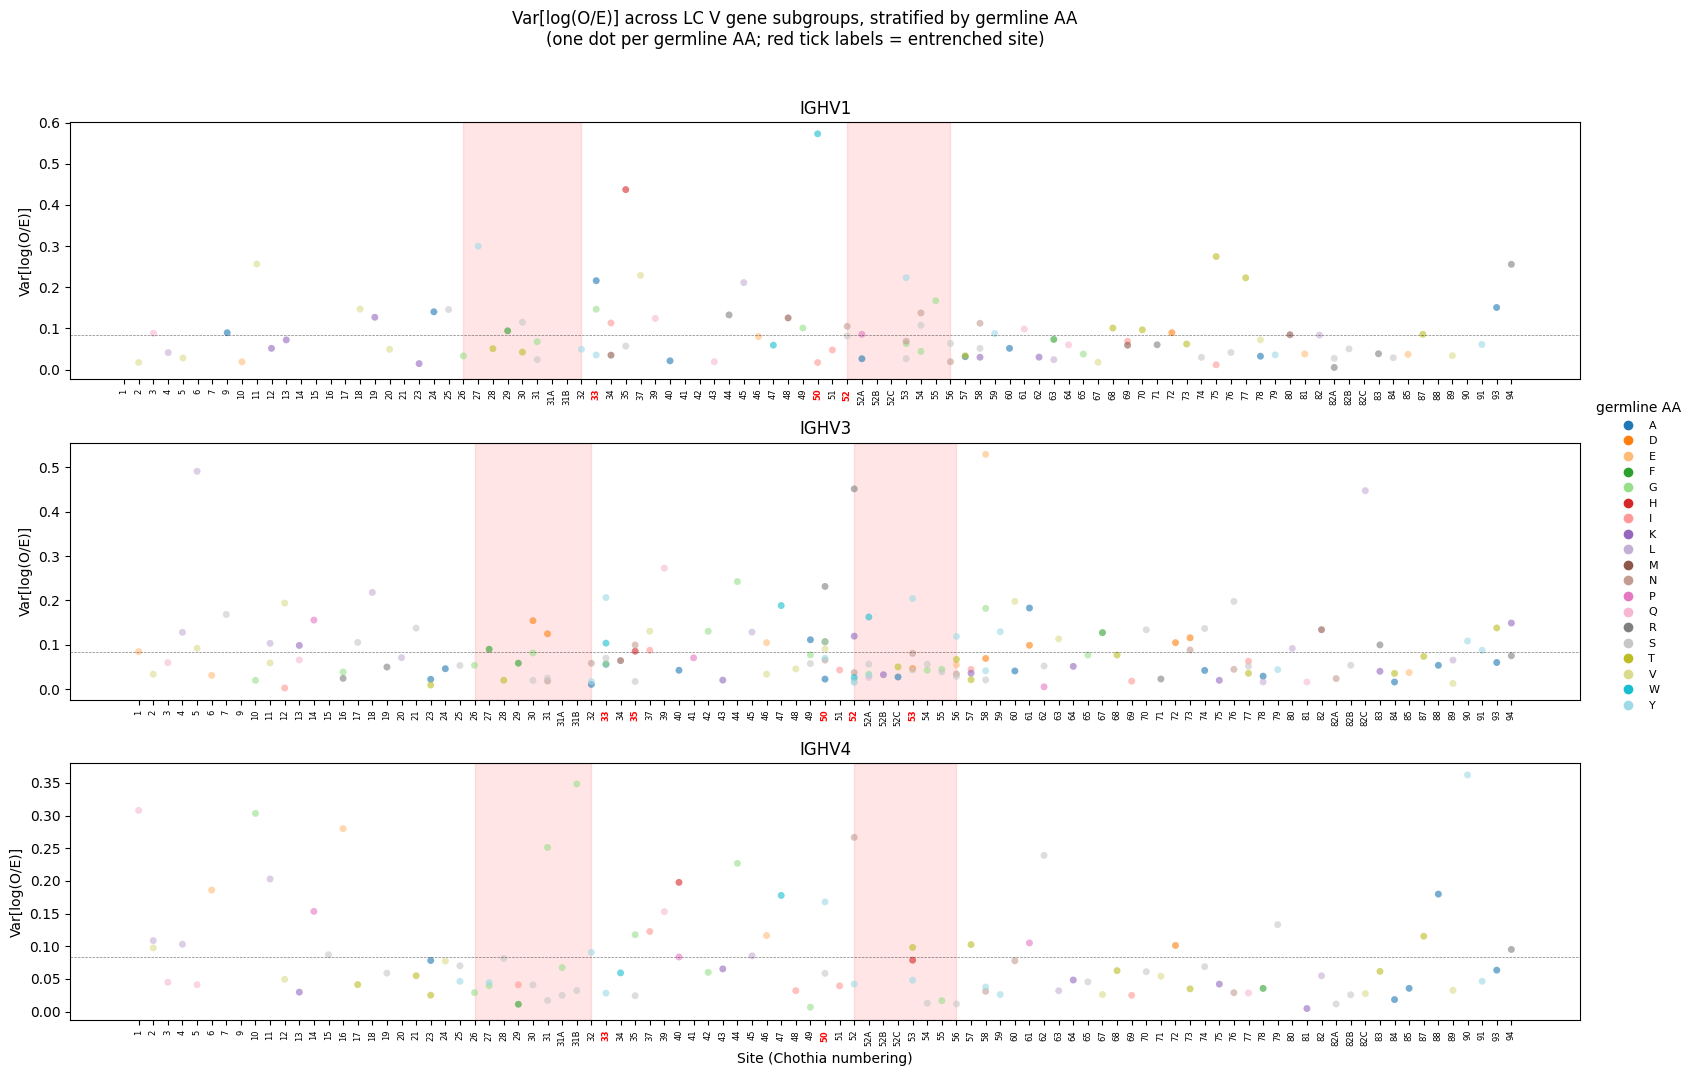

In [ ]:
sorted_sites_v = sort_antibody_sites(variance_by_aa['site'].unique())
site_positions_v = {s: i for i, s in enumerate(sorted_sites_v)}

non_ent_v = variance_by_aa[variance_by_aa.category == 'non_entrenched']['var_log_ratio']
baseline_var_aa = non_ent_v.mean()

fig, axes = plt.subplots(len(v_families), 1, figsize=(16, 3.5 * len(v_families)))

for ax, vf in zip(axes, v_families):
    vf_data = variance_by_aa[variance_by_aa.v_family == vf]
    add_cdr_shading(ax, sorted_sites_v, numbering_scheme=numbering_scheme)
    ax.axhline(baseline_var_aa, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

    xs = [site_positions_v[s] for s in vf_data['site']]
    ys = vf_data['var_log_ratio'].values
    cs = [aa_colors.get(aa, 'black') for aa in vf_data['parent_aa']]
    ax.scatter(xs, ys, c=cs, marker='o', s=25, alpha=0.6, edgecolors='none')

    ax.set_ylabel('Var[log(O/E)]')
    ax.set_title(f'{vf}')
    ax.set_xticks(range(len(sorted_sites_v)))
    ax.set_xticklabels(sorted_sites_v, rotation=90, fontsize=6)

axes[-1].set_xlabel('Site (Chothia numbering)')

fig.canvas.draw()
for ax, vf in zip(axes, v_families):
    highlight_entrenched_ticks(ax, sorted_sites_v, within_site_keys, vf)

make_aa_legend(fig, variance_by_aa['parent_aa'].unique())
fig.suptitle('Var[log(O/E)] across LC V gene subgroups, stratified by germline AA'
             '\n(one dot per germline AA; red tick labels = entrenched site)',
             y=1.02)
plt.tight_layout()
plt.show()

### Noise-corrected variance

Subtract the Poisson noise floor $\overline{1/O}$ from each triple's sample variance.
Triples with $\text{var\_corrected} \leq 0$ are consistent with pure sampling noise.

In [7]:
non_ent_vc = variance_by_aa[variance_by_aa.category == 'non_entrenched']['var_corrected']
ent_vc = variance_by_aa[variance_by_aa.category == 'entrenched_site']['var_corrected']

print('Noise-corrected variance (s\u00b2 \u2212 mean(1/O)):')
print(f'  Non-entrenched (n={len(non_ent_vc)}): '
      f'mean={non_ent_vc.mean():+.4f}, median={non_ent_vc.median():+.4f}')
print(f'  Entrenched     (n={len(ent_vc)}): '
      f'mean={ent_vc.mean():+.4f}, median={ent_vc.median():+.4f}')
print()
print('Fraction with var_corrected <= 0 (consistent with noise):')
print(f'  non-entrenched: {(non_ent_vc <= 0).mean():.1%}')
print(f'  entrenched:     {(ent_vc <= 0).mean():.1%}')

Noise-corrected variance (s² − mean(1/O)):
  Non-entrenched (n=325): mean=+0.0080, median=-0.0048
  Entrenched     (n=35): mean=+0.0246, median=-0.0047

Fraction with var_corrected <= 0 (consistent with noise):
  non-entrenched: 57.2%
  entrenched:     54.3%


---
## Permutation test: site-label shuffle

Null hypothesis: entrenched sites are not special — their mean statistic
is drawn from the same distribution as non-entrenched sites.

Procedure: shuffle site labels (entrenched vs. non-entrenched) while keeping
all germline-AA dots at a site together. This preserves within-site correlation
and naturally handles the fact that entrenched sites have more germline AAs per site.

In [8]:
def permutation_test_site_shuffle(df, value_col, take_abs=False,
                                   n_permutations=10000, seed=42):
    """Permutation test by shuffling site labels (entrenched vs not).

    Each site keeps all its dots together. We shuffle which sites are called
    'entrenched' vs 'non-entrenched', recompute the group means, and compare.
    """
    rng = np.random.default_rng(seed)

    vals = df[value_col].abs().values if take_abs else df[value_col].values
    cats = df['category'].values

    site_keys = list(df[['site', 'v_family']].drop_duplicates().itertuples(index=False, name=None))
    site_to_rows = {}
    site_to_cat = {}
    for sk in site_keys:
        mask = (df['site'] == sk[0]) & (df['v_family'] == sk[1])
        site_to_rows[sk] = np.where(mask.values)[0]
        site_to_cat[sk] = df.loc[mask.index[mask], 'category'].iloc[0]

    ent_mask = cats == 'entrenched_site'
    obs_gap = vals[ent_mask].mean() - vals[~ent_mask].mean()

    ent_sites = [sk for sk in site_keys if site_to_cat[sk] == 'entrenched_site']
    n_ent_sites = len(ent_sites)

    perm_gaps = np.empty(n_permutations)
    all_site_keys = list(site_keys)
    for i in range(n_permutations):
        rng.shuffle(all_site_keys)
        perm_ent_sites = set(all_site_keys[:n_ent_sites])
        perm_ent_rows = np.concatenate([site_to_rows[sk] for sk in perm_ent_sites])
        perm_non_rows = np.concatenate([site_to_rows[sk] for sk in all_site_keys[n_ent_sites:]])
        perm_gaps[i] = vals[perm_ent_rows].mean() - vals[perm_non_rows].mean()

    p_value = (np.sum(perm_gaps >= obs_gap) + 1) / (n_permutations + 1)
    return {'observed_gap': obs_gap, 'permuted_gaps': perm_gaps,
            'p_value': p_value, 'n_ent_sites': n_ent_sites,
            'n_total_sites': len(site_keys)}

In [9]:
res_delta = permutation_test_site_shuffle(
    well_powered_aa, 'delta_log_ratio', take_abs=True, n_permutations=10000, seed=0)
print('Analysis A: |\u0394 log(O/E)| [\u03ba \u2212 \u03bb]')
print(f'  Observed gap (ent - non-ent): {res_delta["observed_gap"]:+.4f}')
print(f'  p-value (site-label shuffle): {res_delta["p_value"]:.4f}')
print(f'  ({res_delta["n_ent_sites"]} entrenched sites out of {res_delta["n_total_sites"]} total)')
print()

res_var = permutation_test_site_shuffle(
    variance_by_aa, 'var_log_ratio', take_abs=False, n_permutations=10000, seed=1)
print('Analysis B: Var[log(O/E)] across LC V gene subgroups')
print(f'  Observed gap (ent - non-ent): {res_var["observed_gap"]:+.4f}')
print(f'  p-value (site-label shuffle): {res_var["p_value"]:.4f}')
print(f'  ({res_var["n_ent_sites"]} entrenched sites out of {res_var["n_total_sites"]} total)')

Analysis A: |Δ log(O/E)| [κ − λ]
  Observed gap (ent - non-ent): -0.0008
  p-value (site-label shuffle): 0.4775
  (10 entrenched sites out of 260 total)



Analysis B: Var[log(O/E)] across LC V gene subgroups
  Observed gap (ent - non-ent): +0.0264
  p-value (site-label shuffle): 0.1160
  (10 entrenched sites out of 255 total)


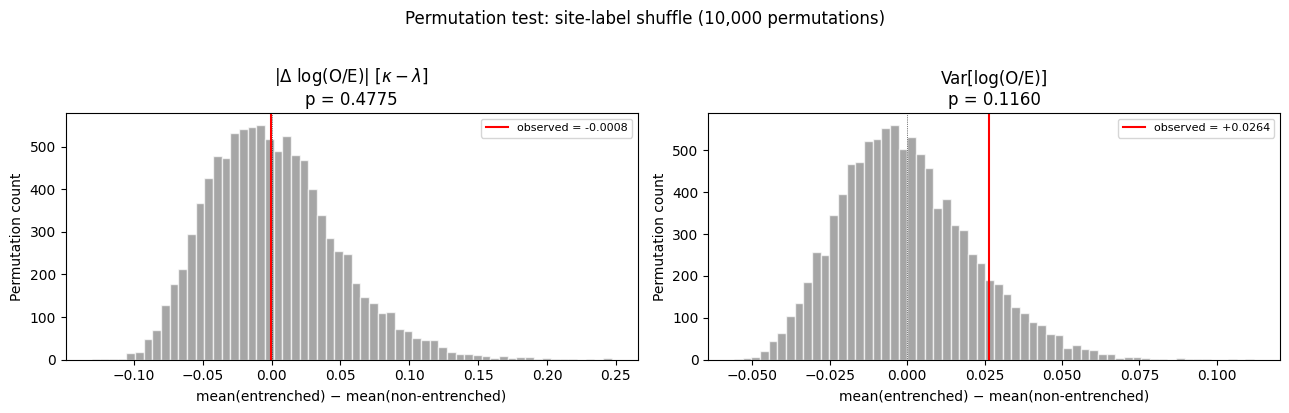

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, res, title in [
    (axes[0], res_delta, r'|$\Delta$ log(O/E)| [$\kappa - \lambda$]'),
    (axes[1], res_var, 'Var[log(O/E)]'),
]:
    ax.hist(res['permuted_gaps'], bins=60, color='grey', alpha=0.7, edgecolor='white')
    ax.axvline(res['observed_gap'], color='red', linestyle='-', linewidth=1.5,
               label=f'observed = {res["observed_gap"]:+.4f}')
    ax.axvline(0, color='black', linestyle=':', linewidth=0.5)
    ax.set_xlabel('mean(entrenched) \u2212 mean(non-entrenched)')
    ax.set_ylabel('Permutation count')
    ax.set_title(f'{title}\np = {res["p_value"]:.4f}')
    ax.legend(fontsize=8)

fig.suptitle('Permutation test: site-label shuffle (10,000 permutations)', y=1.02)
plt.tight_layout()
plt.show()

---
## Outlier detection: MAD-based robust z-scores

Fit a robust location (median) and scale (MAD × 1.4826) to the
population of all dots, then flag dots whose robust z-score is unusually
large. Apply BH correction across all dots to control false discovery rate.

In [11]:
delta_vals = well_powered_aa['delta_log_ratio'].values

med_d = np.median(delta_vals)
mad_d = np.median(np.abs(delta_vals - med_d))
sigma_d = 1.4826 * mad_d

well_powered_aa = well_powered_aa.copy()
well_powered_aa['z_robust'] = (well_powered_aa['delta_log_ratio'] - med_d) / sigma_d
well_powered_aa['abs_z_robust'] = well_powered_aa['z_robust'].abs()
well_powered_aa['p_robust'] = 2 * stats.norm.sf(well_powered_aa['abs_z_robust'])

reject, p_bh, _, _ = multipletests(well_powered_aa['p_robust'], method='fdr_bh')
well_powered_aa['p_bh'] = p_bh
well_powered_aa['outlier_bh'] = reject

print('Analysis A: \u0394 log(O/E) [\u03ba - \u03bb]')
print(f'  Population: median={med_d:.4f}, MAD-sigma={sigma_d:.4f}, n={len(delta_vals)}')
print(f'  Outliers at BH < 0.05: {reject.sum()}')
n_ent_outliers = well_powered_aa.loc[reject, 'category'].eq('entrenched_site').sum()
print(f'    of which entrenched: {n_ent_outliers}')
print()

outliers_a = well_powered_aa[well_powered_aa['outlier_bh']].sort_values('abs_z_robust', ascending=False)
if len(outliers_a) > 0:
    print(outliers_a[['site', 'v_family', 'parent_aa', 'category',
                       'delta_log_ratio', 'z_robust', 'p_bh']].to_string(index=False))
else:
    print('No outliers at BH < 0.05.')
    print()
    print('Top 10 by |z_robust|:')
    top10 = well_powered_aa.nlargest(10, 'abs_z_robust')
    print(top10[['site', 'v_family', 'parent_aa', 'category',
                  'delta_log_ratio', 'z_robust', 'p_robust', 'p_bh']].to_string(index=False))

Analysis A: Δ log(O/E) [κ - λ]
  Population: median=-0.0019, MAD-sigma=0.1720, n=368
  Outliers at BH < 0.05: 19
    of which entrenched: 3

site v_family parent_aa        category  delta_log_ratio  z_robust         p_bh
  90    IGHV4         Y  non_entrenched        -1.225678 -7.116646 4.069524e-10
  44    IGHV3         G  non_entrenched         1.058083  6.164373 1.302040e-07
  42    IGHV3         G  non_entrenched         0.822825  4.796251 1.983058e-04
  52    IGHV3         R entrenched_site        -0.773690 -4.488146 6.609800e-04
  58    IGHV3         E  non_entrenched        -0.757339 -4.393059 8.226030e-04
  44    IGHV4         G  non_entrenched         0.657887  3.837069 6.862078e-03
  37    IGHV1         V  non_entrenched         0.650377  3.793394 6.862078e-03
  45    IGHV1         L  non_entrenched         0.650213  3.792438 6.862078e-03
  25    IGHV1         S  non_entrenched        -0.629244 -3.648132 1.080094e-02
   6    IGHV4         E  non_entrenched         0.614521  3

In [12]:
log_var_vals = np.log(variance_by_aa['var_log_ratio'].values + 1e-9)

med_v = np.median(log_var_vals)
mad_v = np.median(np.abs(log_var_vals - med_v))
sigma_v = 1.4826 * mad_v

variance_by_aa = variance_by_aa.copy()
variance_by_aa['z_robust'] = (np.log(variance_by_aa['var_log_ratio'] + 1e-9) - med_v) / sigma_v
variance_by_aa['abs_z_robust'] = variance_by_aa['z_robust'].abs()
variance_by_aa['p_robust'] = stats.norm.sf(variance_by_aa['z_robust'])

reject_v, p_bh_v, _, _ = multipletests(variance_by_aa['p_robust'], method='fdr_bh')
variance_by_aa['p_bh'] = p_bh_v
variance_by_aa['outlier_bh'] = reject_v

print('Analysis B: Var[log(O/E)] (one-sided, high variance)')
print(f'  Population (log-space): median={med_v:.4f}, MAD-sigma={sigma_v:.4f}, n={len(log_var_vals)}')
print(f'  Outliers at BH < 0.05: {reject_v.sum()}')
n_ent_outliers_v = variance_by_aa.loc[reject_v, 'category'].eq('entrenched_site').sum()
print(f'    of which entrenched: {n_ent_outliers_v}')
print()

outliers_b = variance_by_aa[variance_by_aa['outlier_bh']].sort_values('z_robust', ascending=False)
if len(outliers_b) > 0:
    print(outliers_b[['site', 'v_family', 'parent_aa', 'category',
                       'var_log_ratio', 'var_corrected', 'z_robust', 'p_bh']].to_string(index=False))
else:
    print('No outliers at BH < 0.05.')
    print()
    print('Top 10 by z_robust:')
    top10v = variance_by_aa.nlargest(10, 'z_robust')
    print(top10v[['site', 'v_family', 'parent_aa', 'category',
                   'var_log_ratio', 'var_corrected', 'z_robust', 'p_robust', 'p_bh']].to_string(index=False))

Analysis B: Var[log(O/E)] (one-sided, high variance)
  Population (log-space): median=-2.8108, MAD-sigma=0.8339, n=360
  Outliers at BH < 0.05: 0
    of which entrenched: 0

No outliers at BH < 0.05.

Top 10 by z_robust:
site v_family parent_aa        category  var_log_ratio  var_corrected  z_robust  p_robust     p_bh
  50    IGHV1         W entrenched_site       0.572888       0.464302  2.702547  0.003441 0.520964
  58    IGHV3         E  non_entrenched       0.528653       0.422301  2.606186  0.004578 0.520964
   5    IGHV3         L  non_entrenched       0.490582       0.372349  2.516562  0.005925 0.520964
  52    IGHV3         R entrenched_site       0.451033       0.338907  2.415770  0.007851 0.520964
 82C    IGHV3         L  non_entrenched       0.447003       0.319314  2.405006  0.008086 0.520964
  35    IGHV1         H  non_entrenched       0.437368       0.299908  2.378877  0.008683 0.520964
  90    IGHV4         Y  non_entrenched       0.362338       0.243588  2.153198  0.015

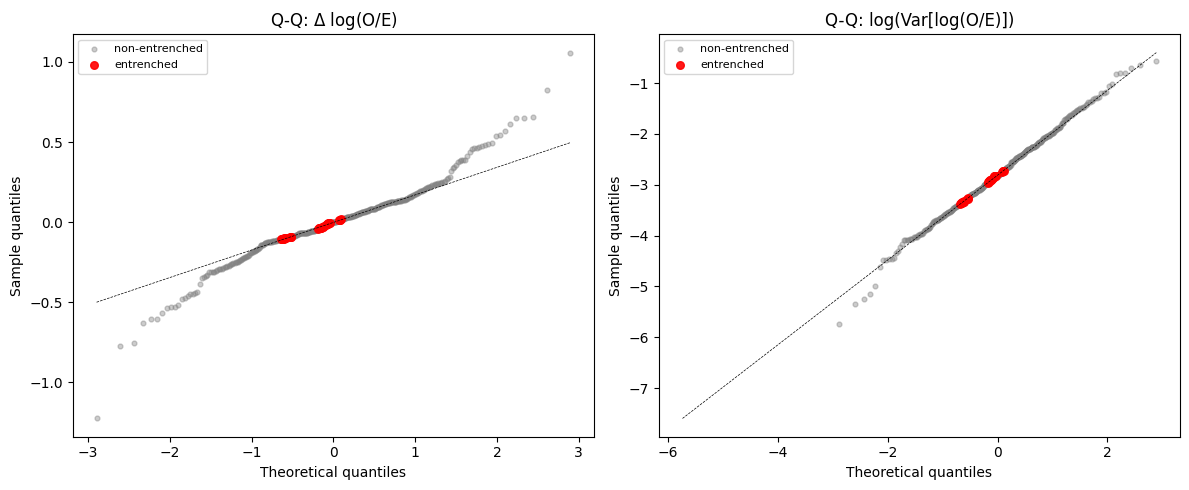

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
osm, osr = stats.probplot(delta_vals, dist='norm', fit=False)
ent_mask_a = (well_powered_aa['category'] == 'entrenched_site').values
ax.scatter(osm[~ent_mask_a], osr[~ent_mask_a], s=12, alpha=0.4, color='grey', label='non-entrenched')
ax.scatter(osm[ent_mask_a], osr[ent_mask_a], s=30, alpha=0.9, color='red', label='entrenched')
lo, hi = min(osm.min(), osr.min()), max(osm.max(), osr.max())
ax.plot([lo, hi], [lo * sigma_d + med_d, hi * sigma_d + med_d], 'k--', linewidth=0.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title(r'Q-Q: $\Delta$ log(O/E)')
ax.legend(fontsize=8)

ax = axes[1]
osm2, osr2 = stats.probplot(log_var_vals, dist='norm', fit=False)
ent_mask_b = (variance_by_aa['category'] == 'entrenched_site').values
ax.scatter(osm2[~ent_mask_b], osr2[~ent_mask_b], s=12, alpha=0.4, color='grey', label='non-entrenched')
ax.scatter(osm2[ent_mask_b], osr2[ent_mask_b], s=30, alpha=0.9, color='red', label='entrenched')
lo2, hi2 = min(osm2.min(), osr2.min()), max(osm2.max(), osr2.max())
ax.plot([lo2, hi2], [lo2 * sigma_v + med_v, hi2 * sigma_v + med_v], 'k--', linewidth=0.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q: log(Var[log(O/E)])')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()